Linear Regression
MSE: 24.291119474973538
R2 Score: 0.6687594935356317
----------------------------------
Polynomial Regression
MSE: 14.257338169026605
R2 Score: 0.8055829447956191
----------------------------------
Ridge Regression
MSE: 24.31290383049162
R2 Score: 0.6684624359643558
----------------------------------
Lasso Regression
MSE: 25.656739367167678
R2 Score: 0.6501375183238987
----------------------------------


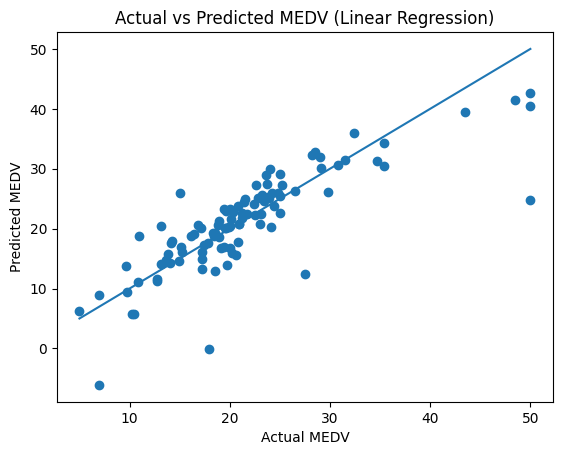

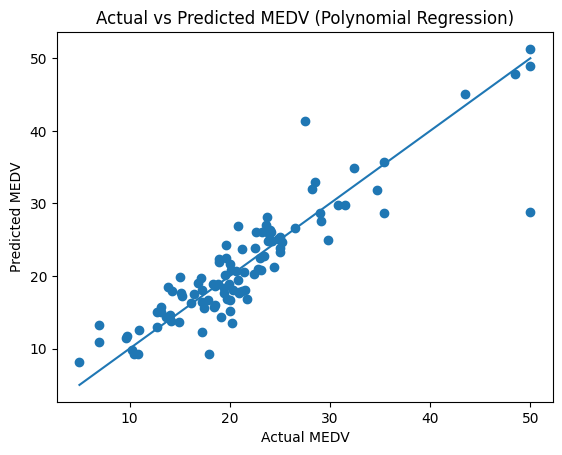

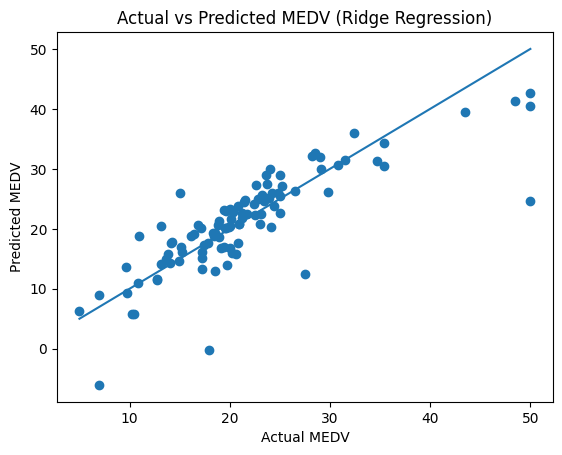

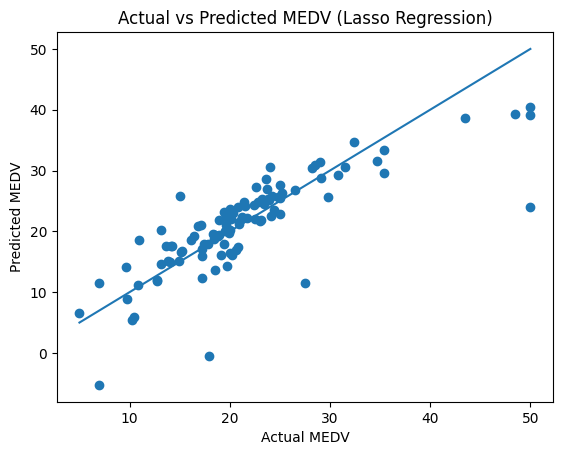

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv(r"C:\Users\Akilan\OneDrive\Documents\MLT\DATA_BASE\BostonHousing.csv")
data = data.dropna()

X = data.drop("medv", axis=1)
y = data["medv"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)
y_pred_poly = poly_model.predict(X_poly_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(X_test_scaled)

def evaluate(model_name, y_test, y_pred):
    print(model_name)
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("----------------------------------")

evaluate("Linear Regression", y_test, y_pred_linear)
evaluate("Polynomial Regression", y_test, y_pred_poly)
evaluate("Ridge Regression", y_test, y_pred_ridge)
evaluate("Lasso Regression", y_test, y_pred_lasso)

models = {
    "Linear": y_pred_linear,
    "Polynomial": y_pred_poly,
    "Ridge": y_pred_ridge,
    "Lasso": y_pred_lasso
}

for name, preds in models.items():
    plt.figure()
    plt.scatter(y_test, preds)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()])
    plt.xlabel("Actual MEDV")
    plt.ylabel("Predicted MEDV")
    plt.title(f"Actual vs Predicted MEDV ({name} Regression)")
    plt.show()